In [1]:
import opensim as osim

In [2]:
def make_pendulum_model():
    model = osim.Model()
    model.setName("pendulum")
    model.setGravity(osim.Vec3(0, -9.81, 0))
    # model.setGravity(osim.Vec3(0, 0, 0))
    ground = model.getGround()

    # Define the pendulum head body
    m = 80 * 0.2  # mass in kg
    J = osim.Inertia(0.01, 0.01, 0.01)  # inertia tensor
    pos_com = osim.Vec3(0, 0, 0)  # center of mass position
    head = osim.Body()
    head.setName("head")
    head.setMass(m)
    head.setInertia(J)
    head.setMassCenter(pos_com)
    model.addBody(head)

    # Define the pin joint
    # Pin joint for rotation of the head
    joint_name = "head_joint"
    parent_physical_frame = ground
    length = 0.4
    location_in_parent = osim.Vec3(0, 0, 0)
    orientation_in_parent = osim.Vec3(0, 0, 0)
    child_physical_frame = head
    location_in_child = osim.Vec3(0, length, 0)
    orientation_in_child = osim.Vec3(0, 0, 0)

    joint = osim.PinJoint(
        joint_name,
        parent_physical_frame,
        location_in_parent,
        orientation_in_parent,
        child_physical_frame,
        location_in_child,
        orientation_in_child,
    )

    model.addJoint(joint)

    # Define coordinate
    coord = joint.updCoordinate()
    coord.setName("q")
    coord.setDefaultValue(0)
    coord.setDefaultSpeedValue(0)

    # Define CoordinateActuator
    act = osim.CoordinateActuator()
    act.setName("torque")
    act.setCoordinate(coord)
    act.setOptimalForce(1)
    act.setMinControl(-1e6)
    act.setMaxControl(1e6)
    model.addForce(act)

    # Define controller
    func = osim.Constant()
    ctrl = osim.PrescribedController()
    ctrl.setName("controller")
    ctrl.addActuator(act)
    ctrl.prescribeControlForActuator("torque", func)
    model.addController(ctrl)

    # Finalize and initialize the model
    model.finalizeConnections()
    state = model.initSystem()
    act.overrideActuation(state, True)

    model.realizePosition(state)
    model.realizeVelocity(state)
    model.realizeAcceleration(state)
    model.realizeDynamics(state)

    # Initialize the Simulation manager
    manager = osim.Manager(model)
    manager.setIntegratorAccuracy(1e-6)
    manager.initialize(state)

    return {"model": model, "state": state, "coord": coord, "actuator": act, "manager": manager}

In [3]:
# OpenSim setup
env = make_pendulum_model()

model = env["model"]
state = env["state"]
coord = env["coord"]
act = env["actuator"]
manager = env["manager"]

print(f"Position:       {coord.getValue(state)} rad")
print(f"Speed:          {coord.getSpeedValue(state)} rad/s")
print(f"Acceleration:   {coord.getAccelerationValue(state)} rad/s²")
print(f"Torque:         {act.getActuation(state)} Nm")

t = state.getTime()
tf = 10
dt = 0.01

t_values = []
q_values = []
omega_values = []
alpha_values = []
torque_values = []

Position:       0.0 rad
Speed:          0.0 rad/s
Acceleration:   0.0 rad/s²
Torque:         0.0 Nm


In [4]:
while t < tf:
    if t < 0.25 * tf:
        act.setOverrideActuation(state, -3.0)
    elif t < 0.75 * tf:
        act.setOverrideActuation(state, 3.0)
    else:
        act.setOverrideActuation(state, -3.0)

    model.realizeDynamics(state)
    model.realizeAcceleration(state)

    state = manager.integrate(t + dt)
    model.realizePosition(state)
    model.realizeVelocity(state)
    model.realizeAcceleration(state)
    model.realizeDynamics(state)

    t = state.getTime()

    t_values.append(t)
    q_values.append(coord.getValue(state))
    omega_values.append(coord.getSpeedValue(state))
    alpha_values.append(coord.getAccelerationValue(state))
    torque_values.append(act.getActuation(state))

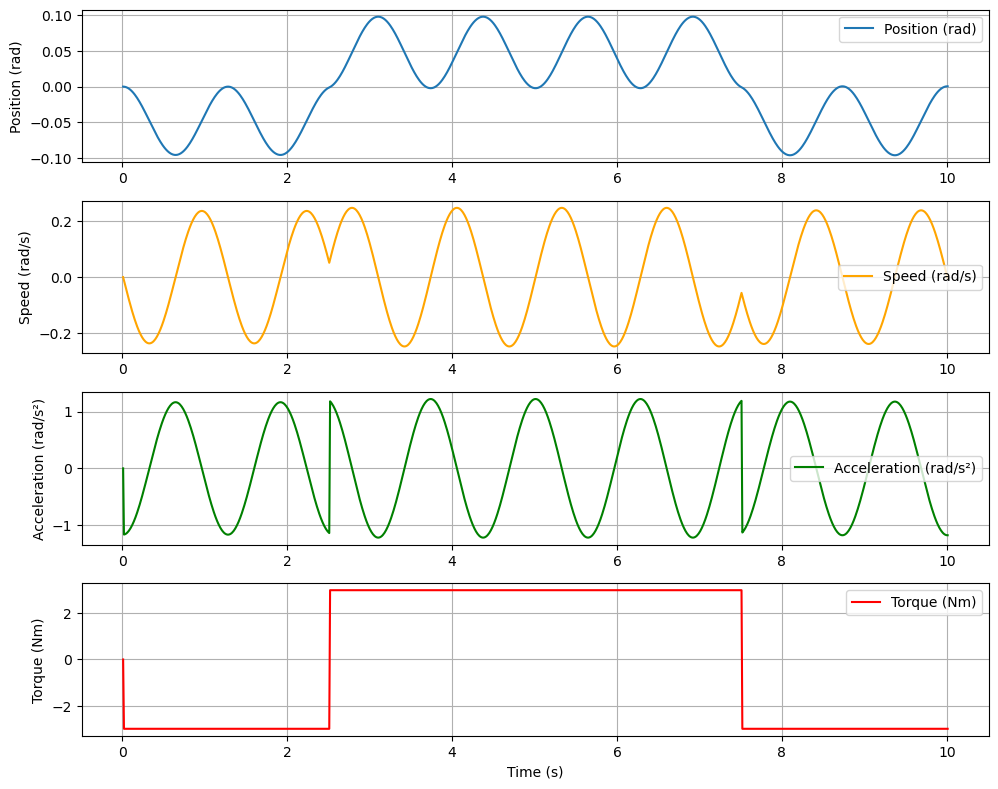

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(t_values, q_values, label="Position (rad)")
plt.ylabel("Position (rad)")
plt.legend()
plt.grid()
plt.subplot(4, 1, 2)
plt.plot(t_values, omega_values, label="Speed (rad/s)", color="orange")
plt.ylabel("Speed (rad/s)")
plt.legend()
plt.grid()
plt.subplot(4, 1, 3)
plt.plot(t_values, alpha_values, label="Acceleration (rad/s²)", color="green")
plt.ylabel("Acceleration (rad/s²)")
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t_values, torque_values, label="Torque (Nm)", color="red")
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# model.printToXML('Models/final_pendulum.osim')

True

In [14]:
from opensim import STOFileAdapter, TimeSeriesTable

table = TimeSeriesTable()
table.setColumnLabels(["q", "q_dot", "q_ddot", "torque"])

for i in range(len(t_values)):
    row = osim.RowVector(4)  # Only 4 columns now (time is separate)
    row[0] = q_values[i]
    row[1] = omega_values[i]
    row[2] = alpha_values[i]
    row[3] = torque_values[i]

    # appendRow takes time as first argument, then the row data
    table.appendRow(t_values[i], row)

# Use STOFileAdapter to write the table
adapter = STOFileAdapter()
adapter.write(table, "Results/pendulum_results.sto")

In [15]:
# Create .mot file for visualization in OpenSim GUI
mot_table = TimeSeriesTable()
mot_table.setColumnLabels(["q", "q_dot", "q_ddot", "torque"])
for i in range(len(t_values)):
    row = osim.RowVector(4)  # 4 columns including time
    # row[0] = t_values[i]
    row[0] = q_values[i]
    row[1] = omega_values[i]
    row[2] = alpha_values[i]
    row[3] = torque_values[i]

    mot_table.appendRow(t_values[i], row)

adapter = STOFileAdapter()
adapter.write(mot_table, "Results/pendulum_results.mot")